In [1]:
using NCDatasets, Plots, Dates, Downloads

In [2]:
# Collect all downloaded CBOFS files and build timestamps from filename
pat = r"(?:^|[/\\])chesapeake_salinity_(\d{8})_t(\d{2})z_n(\d{3})\.nc$"
files = filter(f -> occursin(pat, f), readdir("datafiles"; join=true))

if isempty(files)
    error("No files found matching chesapeake_salinity_YYYYMMDD_tCCz_nFFF.nc")
end

frames = NamedTuple[]
for f in files
    m = match(pat, f)
    ymd = m.captures[1]
    cyc = parse(Int, m.captures[2])   # cycle hour
    fh  = parse(Int, m.captures[3])   # forecast/nowcast hour
    dt = DateTime(ymd, dateformat"yyyymmdd") + Hour(cyc) + Hour(fh)
    push!(frames, (file=f, dt=dt))
end
sort!(frames, by = x -> x.dt)

# Helper to load one snapshot
function load_surface_salinity(file)
    ds = NCDataset(file)
    lon = ds["lon_rho"][:]
    lat = ds["lat_rho"][:]
    salt = ds["salt"][:, :, end, 1]
    close(ds)

    valid_idx = .!ismissing.(salt) .&& .!isnan.(salt) .&& (salt .< 100)

    if size(lon) == size(valid_idx) && size(lat) == size(valid_idx)
        lon_valid = lon[valid_idx]
        lat_valid = lat[valid_idx]
    elseif ndims(lon) == 1 && length(lon) == length(vec(valid_idx))
        lon2 = reshape(lon, size(valid_idx))
        lat2 = reshape(lat, size(valid_idx))
        lon_valid = lon2[valid_idx]
        lat_valid = lat2[valid_idx]
    else
        lon_valid = vec(lon)[vec(valid_idx)]
        lat_valid = vec(lat)[vec(valid_idx)]
    end

    return lon_valid, lat_valid, Float64.(salt[valid_idx])
end


load_surface_salinity (generic function with 1 method)

In [3]:
# Base transect (24-hour cycle, ~130 km)
# Start at the southeastern-most corner; southern return is offset by the same spacing (0.05°) as leg spacing
transect_lon = [
    -75.95, -75.95, -75.95,  # Start SE corner -> bottom of Leg 1 -> top of Leg 1
    -76.00, -76.00,          # Across top -> down Leg 2
    -76.05, -76.05,          # Across bottom -> up Leg 3
    -76.10, -76.10,          # Across top -> down Leg 4
    -76.15, -76.15,          # Across bottom -> up Leg 5
    -76.20, -76.20, -76.20,  # Across top -> down Leg 6 -> drop to southern return
    -75.95                   # Return east to close loop at start
]

t_lat_max = 37.05;
t_lat_min = 36.90;
t_lat_return = 36.875;  # Southern return line latitude

transect_lat = [
    t_lat_return, t_lat_min, t_lat_max,  # Start SE -> Leg 1 bottom -> Leg 1 top
    t_lat_max, t_lat_min,         # Leg 2 top -> Leg 2 bottom
    t_lat_min, t_lat_max,         # Leg 3 bottom -> Leg 3 top
    t_lat_max, t_lat_min,         # Leg 4 top -> Leg 4 bottom
    t_lat_min, t_lat_max,         # Leg 5 bottom -> Leg 5 top
    t_lat_max, t_lat_min, t_lat_return,  # Leg 6 top -> Leg 6 bottom -> southern return line
    t_lat_return                 # Close loop at SE start
]

# Shift path slightly west and north to avoid land overlap
lon_shift = -0.065   # west
lat_shift =  0.1  # north
transect_lon_shifted = transect_lon .+ lon_shift
transect_lat_shifted = transect_lat .+ lat_shift

lat_min, lat_max = 36.75, 37.5

gr()
anim_zoom = @animate for fr in frames
    lon_valid, lat_valid, salt_valid = load_surface_salinity(fr.file)

    roi = (lat_valid .>= lat_min) .& (lat_valid .<= lat_max)

    if any(roi)
        scatter(
            lon_valid[roi], lat_valid[roi],
            marker_z = salt_valid[roi],
            m = (1.8, :square, stroke(0)),
            c = :viridis,
            clims = (0, 35),
            colorbar = true,
            colorbar_title = "Salinity (PSU)",
            title = "Chesapeake Bay Surface Salinity (Zoomed)\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
            xlabel = "Longitude",
            ylabel = "Latitude",
            ylims = (lat_min, lat_max),
            legend = false,
            size = (700, 500),
            framestyle = :box,
            grid = true
        )

        plot!(
            transect_lon_shifted, transect_lat_shifted;
            lw = 3,
            lc = :red,
            marker = :circle,
            ms = 3,
            label = false
        )
    else
        plot(
            transect_lon_shifted, transect_lat_shifted;
            title = "No ocean points in ROI\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
            xlabel = "Longitude",
            ylabel = "Latitude",
            ylims = (lat_min, lat_max),
            lw = 3,
            lc = :red,
            marker = :circle,
            ms = 3,
            legend = false,
            label = false
        )
    end
end

mp4(anim_zoom, "chesapeake_salinity_zoom_w_path.mp4", fps = 6)

[ Info: Saved animation to c:\Users\kavin\OneDrive\Research\cps\cdc26_ive_intro\code\chesapeake_bay\chesapeake_salinity_zoom_w_path.mp4


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\cps\\cdc26_ive_intro\\code\\chesapeake_bay\\chesapeake_salinity_zoom_w_path.mp4")

In [4]:
# Save one snapshot at the earliest available time for each day
outdir = "snapshots_daily_start"
mkpath(outdir)

# frames is already sorted by datetime in a previous cell
first_frame_by_day = Dict{Date, typeof(frames[1])}()
for fr in frames
    d = Date(fr.dt)
    if !haskey(first_frame_by_day, d)
        first_frame_by_day[d] = fr
    end
end

daily_start_frames = sort(collect(values(first_frame_by_day)), by = x -> x.dt)

for fr in daily_start_frames
    lon_valid, lat_valid, salt_valid = load_surface_salinity(fr.file)
    roi = (lat_valid .>= lat_min) .& (lat_valid .<= lat_max)

    if any(roi)
        p = scatter(
            lon_valid[roi], lat_valid[roi],
            marker_z = salt_valid[roi],
            m = (1.8, :square, stroke(0)),
            c = :viridis,
            clims = (0, 35),
            colorbar = true,
            colorbar_title = "Salinity (PSU)",
            title = "Surface Salinity\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
            xlabel = "Longitude",
            ylabel = "Latitude",
            ylims = (lat_min, lat_max),
            legend = false,
            size = (700, 500),
            framestyle = :box,
            grid = true
        )

        plot!(
            p, transect_lon_shifted, transect_lat_shifted;
            lw = 3,
            lc = :red,
            marker = :circle,
            ms = 3,
            label = false
        )
    else
        p = plot(
            transect_lon_shifted, transect_lat_shifted;
            title = "No ocean points in ROI\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
            xlabel = "Longitude",
            ylabel = "Latitude",
            ylims = (lat_min, lat_max),
            lw = 3,
            lc = :red,
            marker = :circle,
            ms = 3,
            legend = false,
            label = false
        )
    end

    outfile = joinpath(outdir, "chesapeake_salinity_startofday_$(Dates.format(fr.dt, dateformat"yyyymmdd_HHMM")).png")
    savefig(p, outfile)
    println("Saved: ", outfile)
end

Saved: snapshots_daily_start\chesapeake_salinity_startofday_20260216_0100.png
Saved: snapshots_daily_start\chesapeake_salinity_startofday_20260217_0000.png
Saved: snapshots_daily_start\chesapeake_salinity_startofday_20260218_0000.png
Saved: snapshots_daily_start\chesapeake_salinity_startofday_20260219_0000.png
Saved: snapshots_daily_start\chesapeake_salinity_startofday_20260220_0000.png
Saved: snapshots_daily_start\chesapeake_salinity_startofday_20260221_0000.png


In [5]:
# Great-circle distance (km) between two lon/lat points
haversine_km(lon1, lat1, lon2, lat2) = begin
    R = 6371.0
    ϕ1, ϕ2 = deg2rad(lat1), deg2rad(lat2)
    dϕ = deg2rad(lat2 - lat1)
    dλ = deg2rad(lon2 - lon1)
    a = sin(dϕ / 2)^2 + cos(ϕ1) * cos(ϕ2) * sin(dλ / 2)^2
    2R * atan(sqrt(a), sqrt(1 - a))
end

# Total one-lap length of the shifted transect (closed loop already includes return point)
total_path_km = sum(
    haversine_km(
        transect_lon_shifted[i], transect_lat_shifted[i],
        transect_lon_shifted[i+1], transect_lat_shifted[i+1]
    ) for i in 1:length(transect_lon_shifted)-1
)

println("Total transect lap length: $(round(total_path_km, digits=2)) km")


# Traverse time at 2 m/s
speed_mps = 1.75
total_path_m = total_path_km * 1000
travel_time_s = total_path_m / speed_mps
travel_time_h = travel_time_s / 3600

println("Time to traverse at $(speed_mps) m/s: $(round(travel_time_h, digits=2)) hours ($(round(travel_time_s/60, digits=1)) minutes)")

Total transect lap length: 150.02 km
Time to traverse at 1.75 m/s: 23.81 hours (1428.7 minutes)


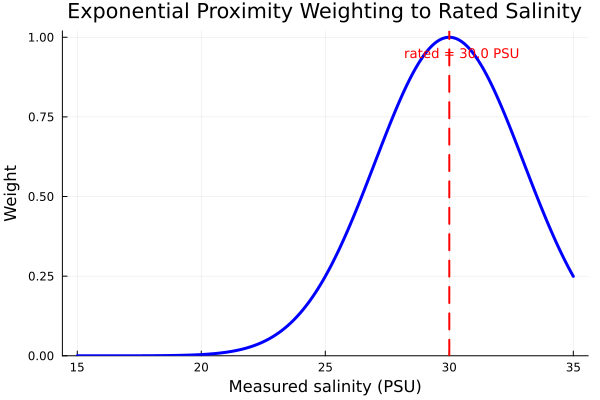

In [6]:
# Weighting function plot

# Rated/target salinity (PSU) and exponential decay width (PSU)
rated_salinity = 30.0
sigma = 3.0

# Exponential proximity weighting: 1 at target, decays toward 0 with distance
weight_exp(s, s_ref=rated_salinity, σ=sigma) = exp(-((s - s_ref)^2) / (2σ^2))

# Plot over a realistic salinity range
s_vals = 15.0:0.1:35.0
w_vals = weight_exp.(s_vals)

plot(
    s_vals, w_vals,
    lw = 3,
    lc = :blue,
    xlabel = "Measured salinity (PSU)",
    ylabel = "Weight",
    title = "Exponential Proximity Weighting to Rated Salinity",
    ylims = (0, 1.02),
    legend = false,
    grid = true
)

vline!([rated_salinity], lc = :red, ls = :dash, lw = 2)
annotate!(rated_salinity + 0.5, 0.95, text("rated = $(rated_salinity) PSU", :red, 9))
savefig("salinity_weighting_function.png")
plot!()

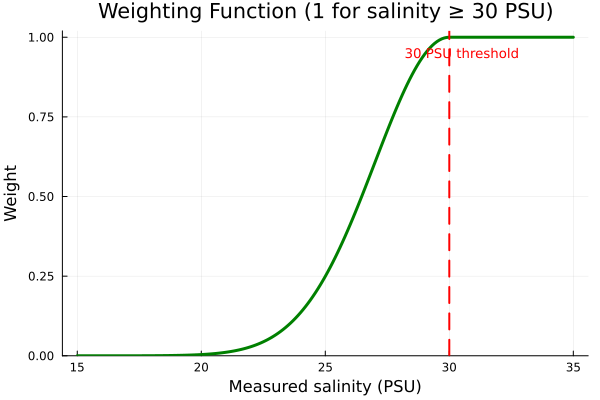

In [7]:
# Weighting function: full weight for salinity >= 30 PSU,
# smooth exponential decay for salinity below 30 PSU.
weight_ge30(s; threshold=30.0, σ=sigma) = s >= threshold ? 1.0 : exp(-((s - threshold)^2) / (2σ^2))

w_vals_ge30 = weight_ge30.(s_vals)

plot(
    s_vals, w_vals_ge30,
    lw = 3,
    lc = :green,
    xlabel = "Measured salinity (PSU)",
    ylabel = "Weight",
    title = "Weighting Function (1 for salinity ≥ 30 PSU)",
    ylims = (0, 1.02),
    legend = false,
    grid = true
)

vline!([30.0], lc = :red, ls = :dash, lw = 2)
annotate!(30.5, 0.95, text("30 PSU threshold", :red, 9))
savefig("salinity_weighting_function_ge30.png")
plot!()

In [8]:
# Clarity Saturation calculation
alpha = 0.4
sens_val = 0.8
q_ss = sqrt(sens_val)/(sqrt(sens_val) + sqrt(alpha))
q_max = 1/(1 + sqrt(alpha))

println("Clarity saturation point q_ss: $(round(q_ss, digits=3))")
println("Clarity maximum q_max: $(round(q_max, digits=3))")

Clarity saturation point q_ss: 0.586
Clarity maximum q_max: 0.613
